In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# Cargar el dataset
df = pd.read_csv("insurance.csv")

df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female':1, 'male':0})
df['region'] = df['region'].map({'southeast':1, 'southwest':0, 'northwest':2, 'northeast':3})


df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2,10600.54830
1334,18,1,31.920,0,0,3,2205.98080
1335,18,1,36.850,0,0,1,1629.83350
1336,21,1,25.800,0,0,0,2007.94500


### Variable dependiente (de salida)

- charges: precios de atención medica facturados por el seguro medico

### Variables indepedientes (predictores o características)

- age: edad del paciente.

- sex: genero del paciente. masculino: 0, femenino: 1

- bmi: indice de grasa corporal (kg / m ^ 2)

- children: numero de niños dependientes del paciente

- smoker: fuma?

- region: region de residencia en US

### Número de muestras (filas):

- 1338 registros en el dataset.

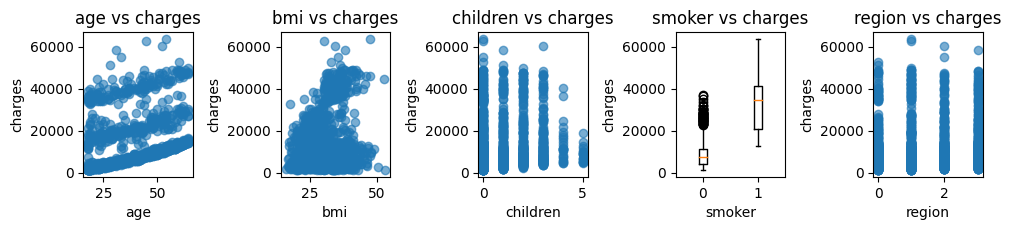

In [28]:
# Seleccionar las variables predictoras y la variable objetivo
X = df[['age', 'bmi', 'children', 'smoker', 'region']]  # Puedes agregar más si es necesario
y = df['charges']

plt.figure(figsize=(12, 4))

for i, var in enumerate(X):
    plt.subplot(2, 6, i + 1)  # Ajusta a 5 porque tienes 5 variables
    
    if var in ['sex', 'smoker']:
        plt.boxplot([y[X[var]==0], y[X[var]==1]], labels=['0', '1'])
    else:
        plt.scatter(df[var], y, alpha=0.6)
    
    plt.xlabel(var)
    plt.ylabel('charges')
    plt.title(f'{var} vs charges')

plt.tight_layout()
plt.show()


### age vs charges

La relación entre la edad de una persona y los costos médicos muestra una tendencia positiva, es decir, en general, las personas de mayor edad tienden a tener mayores gastos médicos. Sin embargo, esta relación no es completamente lineal ni uniforme, ya que se observa una notable dispersión en los datos. Esto indica que personas con edades similares pueden tener costos médicos muy diferentes, lo que sugiere que hay otros factores adicionales que influyen en el valor de los charges. También se observan algunos valores atípicos, donde individuos de edad media o avanzada presentan gastos médicos significativamente más altos que el resto.

### bmi vs charges

La relación entre el índice de masa corporal (BMI) y los costos médicos presenta una tendencia poco definida, aunque se observa que los individuos con valores de BMI más altos tienden a registrar mayores gastos médicos. No obstante, esta relación no es claramente lineal ni uniforme, ya que existe una amplia dispersión en los datos. Esto indica que personas con un BMI similar pueden tener costos médicos muy diferentes, lo que sugiere la influencia de otros factores adicionales. Además, se identifican algunos valores atípicos, donde personas con un BMI elevado presentan gastos médicos significativamente superiores al promedio.

### children vs charges

La relación entre el número de hijos (children) y los costos médicos no muestra una tendencia clara. En general, tener más hijos no parece asociarse de manera evidente con un aumento o disminución en los gastos médicos. Se observa una gran dispersión en los datos para cada cantidad de hijos, indicando que personas con el mismo número de hijos pueden tener costos médicos muy diferentes. Esto sugiere que el número de hijos no es un factor determinante por sí solo y que existen otros elementos que influyen significativamente en el costo médico. También se detectan algunos valores atípicos, donde individuos con pocos o ningún hijo presentan gastos considerablemente elevados.

### sex vs charges

La relación entre el sexo (sex) y los costos médicos muestra que, en general, no existe una diferencia notable entre hombres y mujeres en cuanto a los gastos médicos. Las distribuciones de costos para ambos grupos son muy similares, y presentan una gran variabilidad interna, donde individuos del mismo sexo pueden tener costos médicos muy diferentes. Esto sugiere que el sexo no es un factor determinante por sí solo en el nivel de gastos médicos. Además, se observan algunos valores atípicos en ambos grupos, donde ciertas personas tienen costos significativamente más altos que el resto.

### smoker vs charges

La relación entre ser fumador y los costos médicos muestra una tendencia positiva, es decir, en general, las personas fumadoras tienden a tener mayores gastos médicos. Sin embargo, esta relación no es completamente uniforme, ya que se observa una notable dispersión en los datos. También se observan algunos valores atípicos, donde individuos no fumadores presentan gastos médicos significativamente más altos que el resto de su grupo.

### region vs charges

La relación entre la región y los costos médicos muestra un patrón diferenciado entre las distintas áreas geográficas, codificadas como 0, 1, 2 y 3. En general, se observa cierta variabilidad en los gastos médicos según la región, aunque no hay una tendencia completamente lineal ni uniforme. Se aprecia una notable dispersión en los datos dentro de cada región, lo que indica que personas de la misma zona geográfica pueden tener costos médicos muy diferentes, sugiriendo que hay otros factores adicionales que influyen en el valor de los charges. También se observan algunos valores atípicos en todas las regiones, donde individuos presentan gastos médicos significativamente más altos que la mediana de su zona respectiva.

In [52]:
def cross_val_evaluate(X, y, train_ratio, n_splits=5):
    mse_scores = []
    r2_scores = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(X):
        # Repartimos manualmente los datos según el índice de KFold
        X_fold, y_fold = X[train_index], y[train_index]

        # Repartimos dentro del fold según el train_ratio deseado
        X_train, X_test, y_train, y_test = train_test_split(
            X_fold, y_fold, train_size=train_ratio, random_state=42
        )

        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mse = mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        mse_scores.append(mse)
        r2_scores.append(r2)

    return np.mean(mse_scores), np.mean(r2_scores)

X_array = X.to_numpy() if hasattr(X, "to_numpy") else X
y_array = y.to_numpy() if hasattr(y, "to_numpy") else y

# Evaluamos con distintas proporciones de train
for train_ratio in [0.7, 0.5, 0.4]:
    mse_avg, r2_avg = cross_val_evaluate(X_array, y_array, train_ratio=train_ratio, n_splits=5)
    print(f"Train size: {int(train_ratio*100)}%, Test size: {int((1-train_ratio)*100)}% => MSE avg: {mse_avg:.2f}, R² avg: {r2_avg:.4f}")

Train size: 70%, Test size: 30% => MSE avg: 35059832.31, R² avg: 0.7495
Train size: 50%, Test size: 50% => MSE avg: 35161700.20, R² avg: 0.7534
Train size: 40%, Test size: 60% => MSE avg: 36744628.82, R² avg: 0.7489


In [73]:
def cross_val_evaluate_sgd(X, y, train_ratio=0.7, n_splits=5):
    mse_scores = []
    r2_scores = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_index, test_index in kf.split(X):
        # Simular train/test split según train_ratio
        n_train = int(len(train_index) * train_ratio)
        train_subset = train_index[:n_train]
        test_subset = test_index

        X_train, X_test = X[train_subset], X[test_subset]
        y_train, y_test = y[train_subset], y[test_subset]

        # Entrenar modelo
        model = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, learning_rate='constant', random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mse_scores.append(mean_squared_error(y_test, preds))
        r2_scores.append(r2_score(y_test, preds))
    
    return np.mean(mse_scores), np.mean(r2_scores)

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_array = X_scaled

# Evaluar para diferentes tamaños de entrenamiento
for train_ratio in [0.7, 0.5, 0.4]:
    mse_avg, r2_avg = cross_val_evaluate_sgd(X_array, y_array, train_ratio=train_ratio, n_splits=5)
    print(f"Train size: {int(train_ratio*100)}% => MSE avg: {mse_avg:.2f}, R² avg: {r2_avg:.4f}")

Train size: 70% => MSE avg: 37171100.76, R² avg: 0.7395
Train size: 50% => MSE avg: 38515451.85, R² avg: 0.7286
Train size: 40% => MSE avg: 37893136.28, R² avg: 0.7344


In [6]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_preds = lin_model.predict(X_test)
lin_mse = mean_squared_error(y_test, lin_preds)
print(f"Linear Regression => MSE: {lin_mse:.2f}")

sgd_model = SGDRegressor(penalty='none', max_iter=1000, tol=1e-3, eta0=0.01, learning_rate='constant', random_state=42)
sgd_model.fit(X_train, y_train)
sgd_preds = sgd_model.predict(X_test)
sgd_mse = mean_squared_error(y_test, sgd_preds)
print(f"SGD Regressor => MSE: {sgd_mse:.2f}")

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_preds)
print(f"Ridge Regression => MSE: {ridge_mse:.2f}")

Linear Regression => MSE: 33764476.59
SGD Regressor => MSE: 34859414.35
Ridge Regression => MSE: 33766939.40


In [175]:
# Función para evaluación con K-Fold
def cross_val_evaluate(model, X, y, train_ratio=0.7, n_splits=5):
    mse_scores = []
    r2_scores = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_index, test_index in kf.split(X):
        # Simular train/test split según train_ratio
        n_train = int(len(train_index) * train_ratio)
        train_subset = train_index[:n_train]
        test_subset = test_index

        X_train, X_test = X[train_subset], X[test_subset]
        y_train, y_test = y[train_subset], y[test_subset]

        # Entrenar el modelo
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mse_scores.append(mean_squared_error(y_test, preds))
        r2_scores.append(r2_score(y_test, preds))
    
    return np.mean(mse_scores), np.mean(r2_scores)

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_array = X_scaled
y_array = y.to_numpy() if hasattr(y, "to_numpy") else y

# Evaluar con regresión lineal Ridge (L2)
print("Evaluación con Regresión Lineal Ridge (L2):")
for train_ratio in [0.7, 0.5, 0.4]:
    ridge_model = Ridge(alpha=0.1)  # Puedes ajustar alpha para regularización
    mse_avg, r2_avg = cross_val_evaluate(ridge_model, X_array, y_array, train_ratio=train_ratio, n_splits=5)
    print(f"Train size: {int(train_ratio*100)}% => MSE avg: {mse_avg:.2f}, R² avg: {r2_avg:.4f}")

# Evaluar con SGDRegressor (con regularización L2)
print("\nEvaluación con SGDRegressor con L2 (regularización):")
for train_ratio in [0.7, 0.5, 0.4]:
    sgd_model = SGDRegressor(alpha=0.05, max_iter=1000, tol=1e-3, eta0=0.01, learning_rate='constant', random_state=42)  # alpha controla la regularización L2
    mse_avg, r2_avg = cross_val_evaluate(sgd_model, X_array, y_array, train_ratio=train_ratio, n_splits=5)
    print(f"Train size: {int(train_ratio*100)}% => MSE avg: {mse_avg:.2f}, R² avg: {r2_avg:.4f}")


Evaluación con Regresión Lineal Ridge (L2):
Train size: 70% => MSE avg: 36873708.79, R² avg: 0.7410
Train size: 50% => MSE avg: 37087103.47, R² avg: 0.7393
Train size: 40% => MSE avg: 37096340.09, R² avg: 0.7398

Evaluación con SGDRegressor con L2 (regularización):
Train size: 70% => MSE avg: 37833953.04, R² avg: 0.7348
Train size: 50% => MSE avg: 37567599.40, R² avg: 0.7357
Train size: 40% => MSE avg: 37643235.24, R² avg: 0.7366


In [178]:
# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.7, random_state=42)

# Modelo Ridge con regularización L2
model = Ridge(alpha=0.1)
model.fit(X_train, y_train)

# Predicciones y métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Coeficientes
intercept = model.intercept_
weights = model.coef_

# Mostrar resultados
print("Pesos e Intersección del modelo (Ridge):")
for name, coef in zip(['age', 'bmi', 'children', 'sex', 'smoker', 'region'], weights):
    print(f"  {name}: {coef:.2f}")
print(f"  Intersección (bias): {intercept:.2f}")

# Métricas
print(f"\nMSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

Pesos e Intersección del modelo (Ridge):
  age: 3673.33
  bmi: 2100.73
  children: 512.34
  sex: 9533.51
  smoker: 362.58
  Intersección (bias): 13321.21

MSE: 33764711.50
R²: 0.7697
